In [ ]:
import zipfile

with zipfile.ZipFile("walmart-recruiting-store-sales-forecasting.zip", "r") as zip_ref:
    zip_ref.extractall("walmart_dataset")

In [ ]:
import zipfile
import os

folder = "walmart_dataset"

for file in os.listdir(folder):
    if file.endswith(".zip"):
        with zipfile.ZipFile(os.path.join(folder, file), "r") as zip_ref:
            zip_ref.extractall(folder)

print("All ZIP files extracted!")

All ZIP files extracted!


In [ ]:
!ls walmart_dataset

features.csv	      sampleSubmission.csv.zip	test.csv.zip
features.csv.zip      stores.csv		train.csv
sampleSubmission.csv  test.csv			train.csv.zip


In [ ]:
import pandas as pd

train = pd.read_csv("walmart_dataset/train.csv")
test = pd.read_csv("walmart_dataset/test.csv")
features = pd.read_csv("walmart_dataset/features.csv")
stores = pd.read_csv("walmart_dataset/stores.csv")

In [ ]:
print(train.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [ ]:
print(train.head())
print(train.shape)

print(test.head())
print(features.head())
print(stores.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
(421570, 5)
   Store  Dept        Date  IsHoliday
0      1     1  2012-11-02      False
1      1     1  2012-11-09      False
2      1     1  2012-11-16      False
3      1     1  2012-11-23       True
4      1     1  2012-11-30      False
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDow

In [ ]:
train.info()
features.info()
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4  

In [ ]:
train.isnull().sum()
features.isnull().sum()
stores.isnull().sum()

,0
Store,0
Type,0
Size,0


In [ ]:
train = train.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
train = train.merge(stores, on="Store", how="left")

In [ ]:
test = test.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
test = test.merge(stores, on="Store", how="left")

In [ ]:
train.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [ ]:
train.columns[train.columns.duplicated()]

Index([], dtype='object')

In [ ]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [ ]:
train.shape

(421570, 16)

In [ ]:
train.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479


In [ ]:
train[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].describe()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
count,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000
mean,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079
std,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455
min,0.270000,-265.760000,-29.100000,0.220000,135.160000
25%,2240.270000,41.600000,5.080000,504.220000,1878.440000
50%,5347.450000,192.000000,24.600000,1481.310000,3359.450000
75%,9210.900000,1926.940000,103.990000,3595.040000,5563.800000
max,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000


In [ ]:
train[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].isnull().sum()
train[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].count()

,0
MarkDown1,150681
MarkDown2,111248
MarkDown3,137091
MarkDown4,134967
MarkDown5,151432


In [ ]:
train[train['MarkDown1'].notna()][['Date','MarkDown3']].head(10)

,Date,MarkDown3
92,2011-11-11,215.07
93,2011-11-18,51.98
94,2011-11-25,55805.51
95,2011-12-02,1398.11
96,2011-12-09,105.02
97,2011-12-16,347.37
98,2011-12-23,634.70
99,2011-12-30,260.36
100,2012-01-06,143.10
101,2012-01-13,42.24


In [ ]:
markdown_cols = [
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]

train[markdown_cols] = train[markdown_cols].fillna(0)

In [ ]:
train.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


In [ ]:
train['Date'] = pd.to_datetime(train['Date'])
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [ ]:
train['Year'] = train['Date'].dt.year

train['Month'] = train['Date'].dt.month

train['Week'] = train['Date'].dt.isocalendar().week

train['Day'] = train['Date'].dt.day

train['Quarter'] = train['Date'].dt.quarter
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day,Quarter
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,0.0,211.096358,8.106,A,151315,2010,2,5,5,1
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,0.0,211.242170,8.106,A,151315,2010,2,6,12,1
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,0.0,211.289143,8.106,A,151315,2010,2,7,19,1
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,0.0,211.319643,8.106,A,151315,2010,2,8,26,1
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,0.0,211.350143,8.106,A,151315,2010,3,9,5,1


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['Type'] = le.fit_transform(train['Type'])
train['Type'].unique()

array([0, 1, 2])

In [ ]:
train.dtypes

,0
Store,int64
Dept,int64
Date,datetime64[ns]
Weekly_Sales,float64
IsHoliday,bool
Temperature,float64
Fuel_Price,float64
MarkDown1,float64
MarkDown2,float64
MarkDown3,float64


In [ ]:
train.duplicated().sum()
train = train.drop_duplicates()

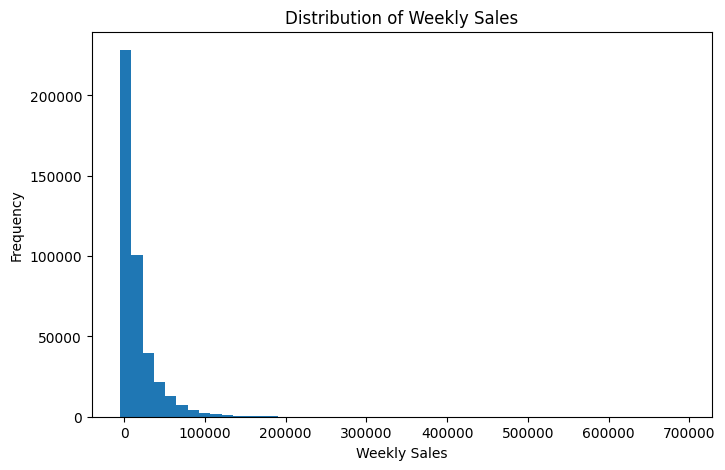

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(train['Weekly_Sales'], bins=50)
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Weekly Sales")
plt.show()

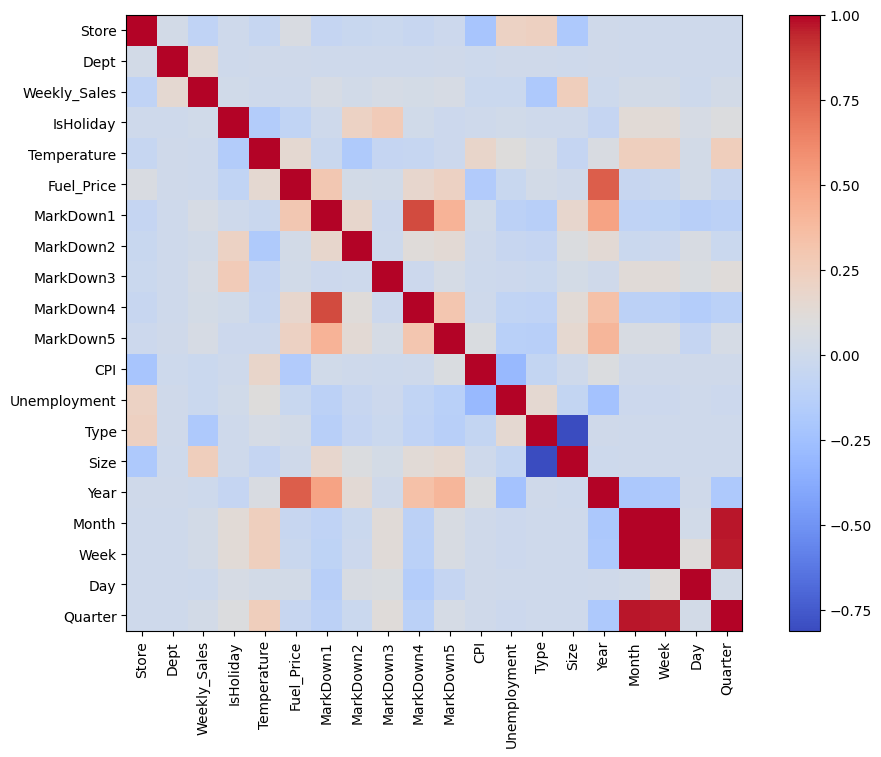

In [ ]:
import matplotlib.pyplot as plt

corr = train.corr(numeric_only=True)

plt.figure(figsize=(12,8))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [ ]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day,Quarter
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,0.0,211.096358,8.106,0,151315,2010,2,5,5,1
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,0.0,211.242170,8.106,0,151315,2010,2,6,12,1
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,0.0,211.289143,8.106,0,151315,2010,2,7,19,1
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,0.0,211.319643,8.106,0,151315,2010,2,8,26,1
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,0.0,211.350143,8.106,0,151315,2010,3,9,5,1


In [ ]:
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month
train['Week'] = train['Date'].dt.isocalendar().week.astype(int)
train['Day'] = train['Date'].dt.day
train['Quarter'] = train['Date'].dt.quarter
train['DayOfWeek'] = train['Date'].dt.dayofweek

test['Year'] = test['Date'].dt.year
test['Month'] = test['Date'].dt.month
test['Week'] = test['Date'].dt.isocalendar().week.astype(int)
test['Day'] = test['Date'].dt.day
test['Quarter'] = test['Date'].dt.quarter
test['DayOfWeek'] = test['Date'].dt.dayofweek

In [ ]:
train['IsHoliday'] = train['IsHoliday'].astype(int)
test['IsHoliday'] = test['IsHoliday'].astype(int)
train['Total_MarkDown'] = (
    train['MarkDown1'] +
    train['MarkDown2'] +
    train['MarkDown3'] +
    train['MarkDown4'] +
    train['MarkDown5']
)

test['Total_MarkDown'] = (
    test['MarkDown1'] +
    test['MarkDown2'] +
    test['MarkDown3'] +
    test['MarkDown4'] +
    test['MarkDown5']
)

In [ ]:
train['Promotion'] = (train['Total_MarkDown'] > 0).astype(int)
test['Promotion'] = (test['Total_MarkDown'] > 0).astype(int)
train['Store_Size_Category'] = pd.qcut(
    train['Size'],
    q=3,
    labels=['Small','Medium','Large']
)

test['Store_Size_Category'] = pd.qcut(
    test['Size'],
    q=3,
    labels=['Small','Medium','Large']
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['Store_Size_Category'] = le.fit_transform(train['Store_Size_Category'])
test['Store_Size_Category'] = le.transform(test['Store_Size_Category'])


In [ ]:
def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

train['Season'] = train['Month'].apply(season)
test['Season'] = test['Month'].apply(season)
le_season = LabelEncoder()

train['Season'] = le_season.fit_transform(train['Season'])
test['Season'] = le_season.transform(test['Season'])
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Year,Month,Week,Day,Quarter,DayOfWeek,Total_MarkDown,Promotion,Store_Size_Category,Season
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,2010,2,5,5,1,4,0.0,0,1,3
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,2010,2,6,12,1,4,0.0,0,1,3
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,2010,2,7,19,1,4,0.0,0,1,3
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,2010,2,8,26,1,4,0.0,0,1,3
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,2010,3,9,5,1,4,0.0,0,1,1


In [ ]:
train.describe()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Year,Month,Week,Day,Quarter,DayOfWeek,Total_MarkDown,Promotion,Store_Size_Category,Season
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,...,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.0,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,0.070358,60.090059,3.361027,2590.074819,879.974298,468.087665,...,2010.968591,6.449510,25.826762,15.673131,2.482767,4.0,6684.041435,0.359210,1.020350,1.461888
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,0.000000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,...,2010.000000,1.000000,1.000000,1.000000,1.000000,4.0,0.000000,0.000000,0.000000,0.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,0.000000,46.680000,2.933000,0.000000,0.000000,0.000000,...,2010.000000,4.000000,14.000000,8.000000,2.000000,4.0,0.000000,0.000000,0.000000,1.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,0.000000,62.090000,3.452000,0.000000,0.000000,0.000000,...,2011.000000,6.000000,26.000000,16.000000,2.000000,4.0,0.000000,0.000000,1.000000,1.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,0.000000,74.280000,3.738000,2809.050000,2.200000,4.540000,...,2012.000000,9.000000,38.000000,23.000000,3.000000,4.0,8075.260000,1.000000,2.000000,2.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,1.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,...,2012.000000,12.000000,52.000000,31.000000,4.000000,4.0,160510.610000,1.000000,2.000000,3.000000
std,12.785297,30.492054,NaN,22711.183519,0.255750,18.447931,0.458515,6052.385934,5084.538801,5528.873453,...,0.796876,3.243217,14.151887,8.753549,1.071341,0.0,14750.941552,0.479769,0.805523,1.070554


In [ ]:
train.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


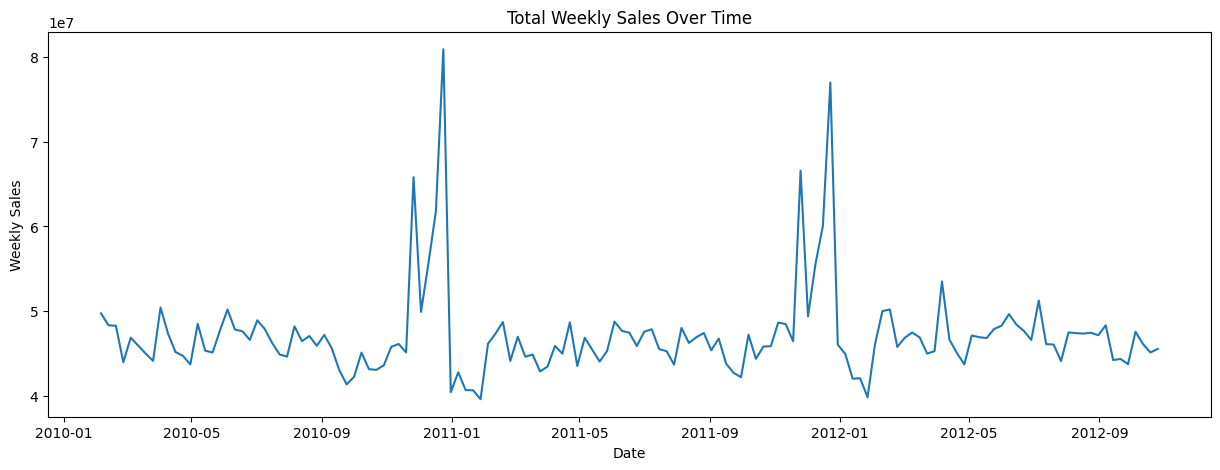

In [ ]:
sales_by_date = train.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(15,5))
plt.plot(sales_by_date)

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.show()

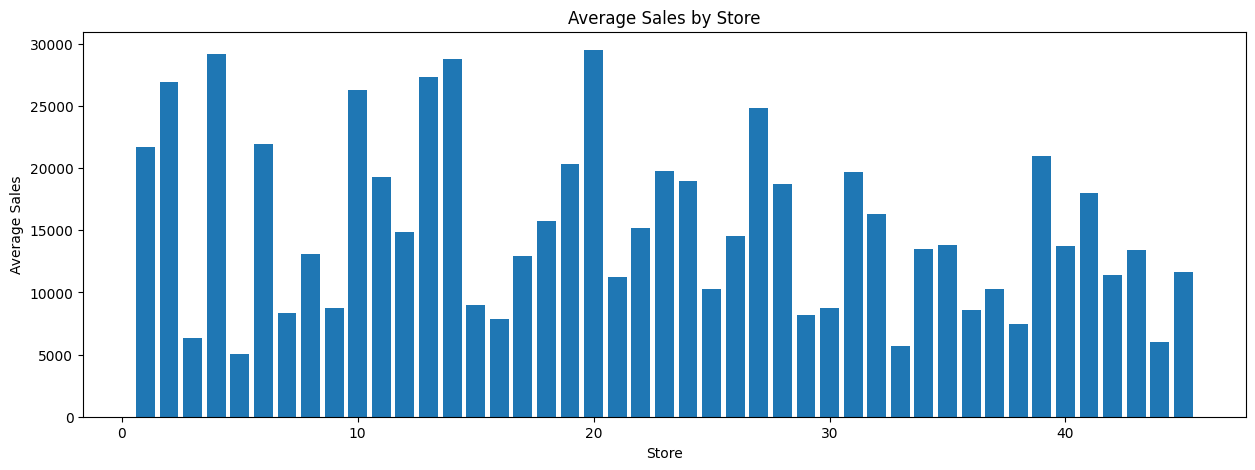

In [ ]:
sales_store = train.groupby('Store')['Weekly_Sales'].mean()

plt.figure(figsize=(15,5))
plt.bar(sales_store.index, sales_store.values)

plt.xlabel("Store")
plt.ylabel("Average Sales")
plt.title("Average Sales by Store")

plt.show()

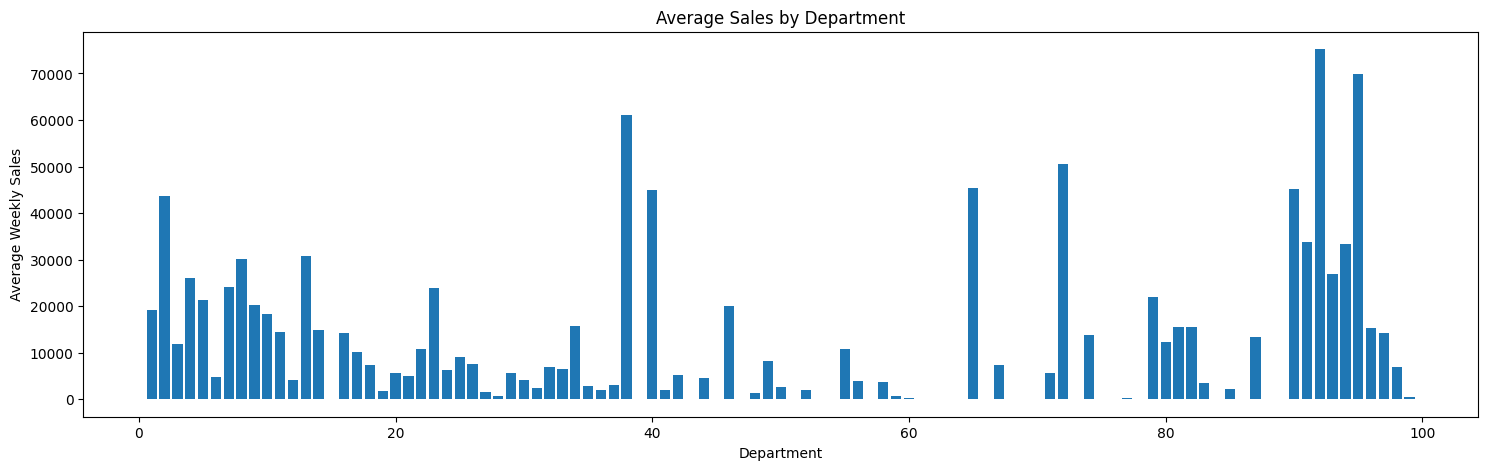

In [ ]:
sales_dept = train.groupby('Dept')['Weekly_Sales'].mean()

plt.figure(figsize=(18,5))
plt.bar(sales_dept.index, sales_dept.values)

plt.xlabel("Department")
plt.ylabel("Average Weekly Sales")
plt.title("Average Sales by Department")

plt.show()

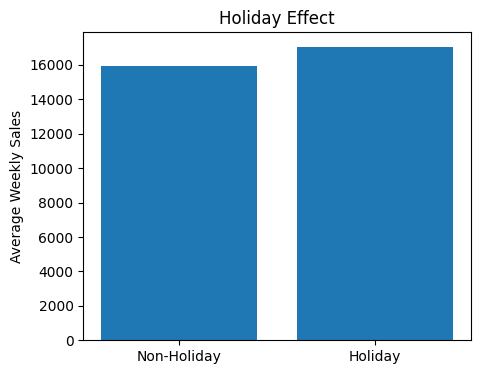

In [ ]:
holiday_sales = train.groupby('IsHoliday')['Weekly_Sales'].mean()

plt.figure(figsize=(5,4))
plt.bar(['Non-Holiday','Holiday'], holiday_sales)

plt.ylabel("Average Weekly Sales")
plt.title("Holiday Effect")

plt.show()

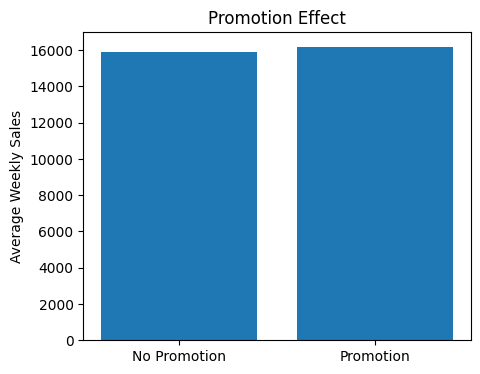

In [ ]:
promotion_sales = train.groupby('Promotion')['Weekly_Sales'].mean()

plt.figure(figsize=(5,4))
plt.bar(['No Promotion','Promotion'], promotion_sales)

plt.ylabel("Average Weekly Sales")
plt.title("Promotion Effect")

plt.show()

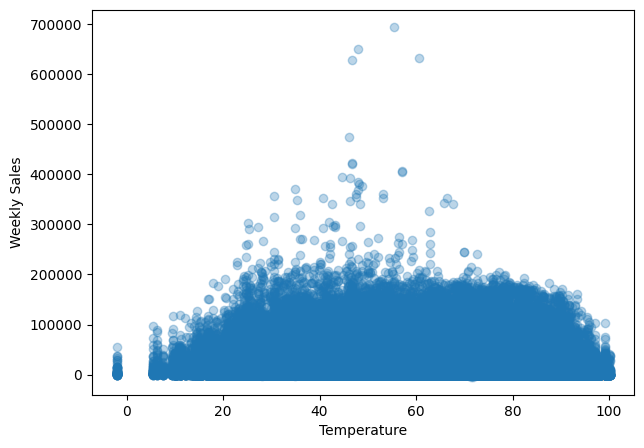

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(train['Temperature'], train['Weekly_Sales'], alpha=0.3)

plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")

plt.show()

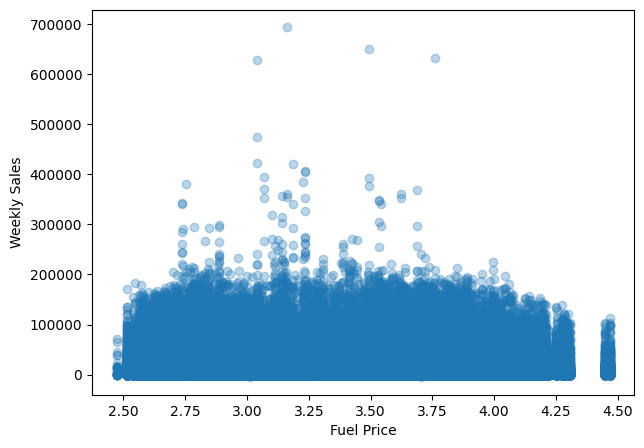

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(train['Fuel_Price'], train['Weekly_Sales'], alpha=0.3)

plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")

plt.show()

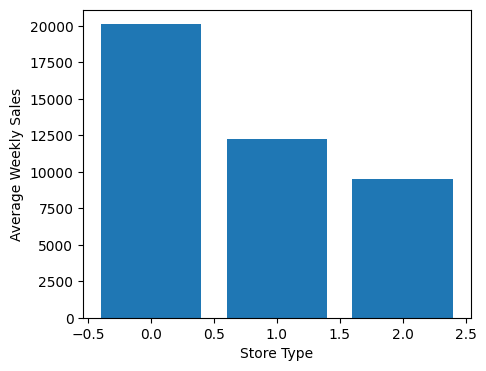

In [ ]:
store_type_sales = train.groupby('Type')['Weekly_Sales'].mean()

plt.figure(figsize=(5,4))
plt.bar(store_type_sales.index, store_type_sales.values)

plt.xlabel("Store Type")
plt.ylabel("Average Weekly Sales")

plt.show()

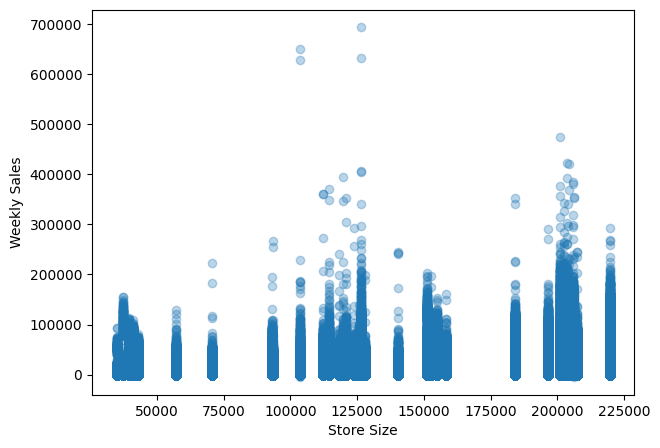

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(train['Size'], train['Weekly_Sales'], alpha=0.3)

plt.xlabel("Store Size")
plt.ylabel("Weekly Sales")

plt.show()

In [ ]:
train = train.sort_values(['Store', 'Dept', 'Date'])

train['Lag_1'] = train.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
train['Lag_2'] = train.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(2)
train['Lag_4'] = train.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(4)
train[['Store','Dept','Date','Weekly_Sales','Lag_1','Lag_2','Lag_4']].head(15)

,Store,Dept,Date,Weekly_Sales,Lag_1,Lag_2,Lag_4
0,1,1,2010-02-05,24924.50,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,24924.50,NaN,NaN
2,1,1,2010-02-19,41595.55,46039.49,24924.50,NaN
3,1,1,2010-02-26,19403.54,41595.55,46039.49,NaN
4,1,1,2010-03-05,21827.90,19403.54,41595.55,24924.50
5,1,1,2010-03-12,21043.39,21827.90,19403.54,46039.49
6,1,1,2010-03-19,22136.64,21043.39,21827.90,41595.55
7,1,1,2010-03-26,26229.21,22136.64,21043.39,19403.54
8,1,1,2010-04-02,57258.43,26229.21,22136.64,21827.90
9,1,1,2010-04-09,42960.91,57258.43,26229.21,21043.39


In [ ]:
train['Rolling_Mean_4'] = (
    train.groupby(['Store','Dept'])['Weekly_Sales']
         .transform(lambda x: x.shift(1).rolling(4).mean())
)
train['Rolling_Mean_8'] = (
    train.groupby(['Store','Dept'])['Weekly_Sales']
         .transform(lambda x: x.shift(1).rolling(8).mean())
)
train['Rolling_STD_4'] = (
    train.groupby(['Store','Dept'])['Weekly_Sales']
         .transform(lambda x: x.shift(1).rolling(4).std())
)

In [ ]:
train['Expanding_Mean'] = (
    train.groupby(['Store','Dept'])['Weekly_Sales']
         .transform(lambda x: x.shift(1).expanding().mean())
)

In [ ]:
train['StoreSize_Temp'] = train['Size'] * train['Temperature']
train['Holiday_Promotion'] = (
    train['IsHoliday'] * train['Promotion']
)
dept_avg = train.groupby('Dept')['Weekly_Sales'].mean()

train['Dept_Avg_Sales'] = train['Dept'].map(dept_avg)
store_avg = train.groupby('Store')['Weekly_Sales'].mean()

train['Store_Avg_Sales'] = train['Store'].map(store_avg)

In [ ]:
store_dept_avg = (
    train.groupby(['Store','Dept'])['Weekly_Sales']
         .mean()
)

train['StoreDept_Avg'] = (
    train.set_index(['Store','Dept'])
         .index.map(store_dept_avg)
)
import numpy as np

train['Month_Sin'] = np.sin(2*np.pi*train['Month']/12)
train['Month_Cos'] = np.cos(2*np.pi*train['Month']/12)
train['Week_Sin'] = np.sin(2*np.pi*train['Week']/52)
train['Week_Cos'] = np.cos(2*np.pi*train['Week']/52)

In [ ]:
train[['Lag_1','Lag_2','Lag_4']].isnull().sum()
train.fillna(0, inplace=True)
train.columns.tolist()

['Store',
 'Dept',
 'Date',
 'Weekly_Sales',
 'IsHoliday',
 'Temperature',
 'Fuel_Price',
 'MarkDown1',
 'MarkDown2',
 'MarkDown3',
 'MarkDown4',
 'MarkDown5',
 'CPI',
 'Unemployment',
 'Type',
 'Size',
 'Year',
 'Month',
 'Week',
 'Day',
 'Quarter',
 'DayOfWeek',
 'Total_MarkDown',
 'Promotion',
 'Store_Size_Category',
 'Season',
 'Lag_1',
 'Lag_2',
 'Lag_4',
 'Rolling_Mean_4',
 'Rolling_Mean_8',
 'Rolling_STD_4',
 'Expanding_Mean',
 'StoreSize_Temp',
 'Holiday_Promotion',
 'Dept_Avg_Sales',
 'Store_Avg_Sales',
 'StoreDept_Avg',
 'Month_Sin',
 'Month_Cos',
 'Week_Sin',
 'Week_Cos']

In [ ]:
train = train.sort_values("Date")
split_date = "2012-06-01"

train_data = train[train["Date"] < split_date]
valid_data = train[train["Date"] >= split_date]
print(train_data.shape)
print(valid_data.shape)

(356489, 42)
(65081, 42)


In [ ]:
feature_cols = [
    'Store',
    'Dept',
    'IsHoliday',
    'Temperature',
    'Fuel_Price',
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5',
    'CPI',
    'Unemployment',
    'Type',
    'Size',
    'Year',
    'Month',
    'Week',
    'Day',
    'Quarter',
    'DayOfWeek',
    'Promotion',
    'Total_MarkDown',
    'Lag_1',
    'Lag_2',
    'Lag_4',
    'Rolling_Mean_4',
    'Rolling_Mean_8',
    'Rolling_STD_4',
    'Expanding_Mean',
    'Store_Avg_Sales',
    'Dept_Avg_Sales',
    'StoreDept_Avg',
    'StoreSize_Temp',
    'Holiday_Promotion',
    'Month_Sin',
    'Month_Cos',
    'Week_Sin',
    'Week_Cos'
]
target = "Weekly_Sales"

X_train = train_data[feature_cols]
y_train = train_data[target]

X_valid = valid_data[feature_cols]
y_valid = valid_data[target]

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_valid)
mae = mean_absolute_error(y_valid, xgb_pred)
rmse = np.sqrt(mean_squared_error(y_valid, xgb_pred))
r2 = r2_score(y_valid, xgb_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"R² % : {r2*100:.2f}%")

MAE  : 1263.20
RMSE : 2602.95
R²   : 0.9860
R² % : 98.60%


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

              Feature  Importance
22              Lag_1    0.423177
31      StoreDept_Avg    0.194123
25     Rolling_Mean_4    0.129622
23              Lag_2    0.102408
24              Lag_4    0.013413
16               Week    0.012950
33  Holiday_Promotion    0.011627
28     Expanding_Mean    0.011456
2           IsHoliday    0.009384
7           MarkDown3    0.007349
37           Week_Cos    0.007151
15              Month    0.006943
30     Dept_Avg_Sales    0.006803
26     Rolling_Mean_8    0.005877
18            Quarter    0.005591


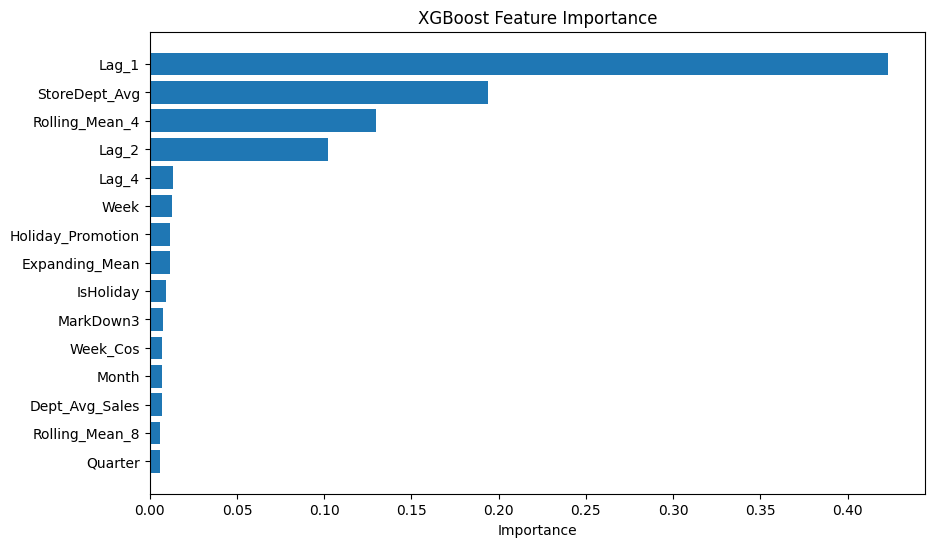

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [1279.33, mae],
    "RMSE": [2659.55, rmse],
    "R²": ["Not Calculated", r2]
})

print(comparison)

           Model          MAE       RMSE              R²
0  Random Forest  1279.330000  2659.5500  Not Calculated
1        XGBoost  1263.203599  2602.9508        0.986035


In [ ]:
import joblib

joblib.dump(xgb, "xgboost_walmart.pkl")

['xgboost_walmart.pkl']

In [ ]:
def predict_sales(data):
    return xgb.predict(data)

In [ ]:
sample = X_valid.iloc[[0]].copy()
prediction = xgb.predict(sample)[0]

In [ ]:
print("========== DEMAND FORECAST ==========")

print(f"Store            : {sample['Store'].values[0]}")
print(f"Department       : {sample['Dept'].values[0]}")
print(f"Forecast Week    : {sample['Week'].values[0]}")

holiday = "Yes" if sample["IsHoliday"].values[0] else "No"

promotion = "Yes" if sample["Promotion"].values[0] else "No"

print(f"Holiday          : {holiday}")
print(f"Promotion        : {promotion}")

print(f"\nPredicted Sales  : {prediction:.2f}")

print("\nModel Used       : XGBoost")
print("Validation R²    : 98.60%")

========== DEMAND FORECAST ==========
Store            : 26
Department       : 2
Forecast Week    : 22
Holiday          : No
Promotion        : Yes

Predicted Sales  : 28994.22

Model Used       : XGBoost
Validation R²    : 98.60%


In [ ]:
import pandas as pd
import numpy as np

train = pd.read_csv('/content/walmart_dataset/train.csv')

train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [ ]:
import numpy as np

# Get unique Store-Department combinations
inventory = train[['Store', 'Dept']].drop_duplicates().reset_index(drop=True)

# Generate realistic inventory values
np.random.seed(42)

inventory['Current_Stock'] = np.random.randint(200, 1000, len(inventory))
inventory['Lead_Time'] = np.random.randint(2, 8, len(inventory))          # days
inventory['Ordering_Cost'] = np.random.randint(100, 500, len(inventory))  # ₹
inventory['Holding_Cost'] = np.random.randint(5, 25, len(inventory))       # ₹ per unit/year
inventory['Supplier_ID'] = np.random.choice(
    ['S001','S002','S003','S004','S005'],
    len(inventory)
)

inventory.head()

,Store,Dept,Current_Stock,Lead_Time,Ordering_Cost,Holding_Cost,Supplier_ID
0,1,1,302,6,433,11,S002
1,1,2,635,5,432,5,S001
2,1,3,470,4,426,11,S002
3,1,4,306,7,114,15,S001
4,1,5,271,4,426,13,S003


In [ ]:
import pandas as pd
import joblib

# Load inventory dataset
inventory = pd.read_csv("inventory.csv")

# Load supplier dataset
supplier = pd.read_csv("supplier.csv")

# Load trained model
model = joblib.load("xgboost_walmart.pkl")

In [ ]:
predicted_demand = 520
store = 1
dept = 1
product = inventory[
    (inventory['Store'] == store) &
    (inventory['Dept'] == dept)
]

product
current_stock = product.iloc[0]['Current_Stock']
lead_time = product.iloc[0]['Lead_Time']
ordering_cost = product.iloc[0]['Ordering_Cost']
holding_cost = product.iloc[0]['Holding_Cost']
supplier_id = product.iloc[0]['Supplier_ID']

In [ ]:
import numpy as np

z = 1.65

daily_demand = predicted_demand / 7

sigma = daily_demand * 0.25

safety_stock = z * sigma * np.sqrt(lead_time)

print(safety_stock)

75.0593642609988


In [ ]:
rop = (daily_demand * lead_time) + safety_stock

print(rop)
annual_demand = predicted_demand * 52
eoq = np.sqrt(
    (2 * annual_demand * ordering_cost)
    / holding_cost
)

print(eoq)

520.7736499752846
1459.0357961837176


In [ ]:
if current_stock <= rop:
    print("Reorder Required")
    print("Recommended Order Quantity:", round(eoq))
else:
    print("No Reorder Required")
best_supplier = supplier[
    supplier['Supplier_ID'] == supplier_id
]

best_supplier

Reorder Required
Recommended Order Quantity: 1459


,Supplier_ID,Supplier_Name,Cost_Per_Unit,Delivery_Time,Reliability
1,S002,Global Supply,9,5,90


In [ ]:
print("========== INVENTORY REPORT ==========")

print("Store:", store)
print("Department:", dept)

print("Predicted Demand:", round(predicted_demand))
print("Current Stock:", current_stock)

print("Safety Stock:", round(safety_stock))
print("Reorder Point:", round(rop))
print("EOQ:", round(eoq))

if current_stock <= rop:
    print("Status: REORDER REQUIRED")
else:
    print("Status: STOCK SUFFICIENT")

print("\nSupplier Recommendation")

print(best_supplier)

========== INVENTORY REPORT ==========
Store: 1
Department: 1
Predicted Demand: 520
Current Stock: 302
Safety Stock: 75
Reorder Point: 521
EOQ: 1459
Status: REORDER REQUIRED

Supplier Recommendation
  Supplier_ID  Supplier_Name  Cost_Per_Unit  Delivery_Time  Reliability
1        S002  Global Supply              9              5           90


In [ ]:
print(type(model))

<class 'xgboost.sklearn.XGBRegressor'>


In [ ]:
print(model.feature_names_in_)

['Store' 'Dept' 'IsHoliday' 'Temperature' 'Fuel_Price' 'MarkDown1'
 'MarkDown2' 'MarkDown3' 'MarkDown4' 'MarkDown5' 'CPI' 'Unemployment'
 'Type' 'Size' 'Year' 'Month' 'Week' 'Day' 'Quarter' 'DayOfWeek'
 'Promotion' 'Total_MarkDown' 'Lag_1' 'Lag_2' 'Lag_4' 'Rolling_Mean_4'
 'Rolling_Mean_8' 'Rolling_STD_4' 'Expanding_Mean' 'Store_Avg_Sales'
 'Dept_Avg_Sales' 'StoreDept_Avg' 'StoreSize_Temp' 'Holiday_Promotion'
 'Month_Sin' 'Month_Cos' 'Week_Sin' 'Week_Cos']


In [ ]:
X_train.to_csv("processed_features.csv", index=False)
y_train.to_csv("processed_target.csv", index=False)

In [ ]:
pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import mlflow
import mlflow.sklearn
mlflow.start_run()

2026/07/21 15:01:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/21 15:01:33 INFO mlflow.store.db.utils: Updating database tables


<ActiveRun: >

In [ ]:
mlflow.log_param("Model","XGBoost")
mlflow.log_param("Features",len(feature_cols))
mlflow.log_metric("R2",r2)
mlflow.log_metric("MAE",mae)
mlflow.log_metric("RMSE",rmse)

In [ ]:
import mlflow.xgboost

mlflow.xgboost.log_model(
    xgb_model=model,
    name="DemandForecastModel"
)

In [ ]:
mlflow.end_run()

In [ ]:
import mlflow
import mlflow.xgboost

with mlflow.start_run():

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("max_depth", model.get_params()["max_depth"])
    mlflow.log_param("learning_rate", model.get_params()["learning_rate"])

    mlflow.log_metric("R2", r2)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)

    mlflow.xgboost.log_model(
        xgb_model=model,
        name="DemandForecastModel"
    )